In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pipeline import get_fitted_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_curve, auc
import warnings
from sklearn.exceptions import ConvergenceWarning


warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)


In [2]:
raw_df = pd.read_csv(r"/Users/loganheydt/Desktop/Data/GitHub/Titanic-Prediction/Data/test.csv")

df = pd.read_csv(r"/Users/loganheydt/Desktop/Data/GitHub/Titanic-Prediction/Data/train.csv")
modeling_df = df.copy()

In [3]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [4]:
drop_cols = ['PassengerId','Cabin', 'Name', 'Title', 'SibSp', 'Parch']
one_hot_cols = ['Sex', 'Embarked', 'cabin_level']
impute_cols = ['Age']
scaling_cols = ['Age', 'Fare', 'family_size']
title_cats = ['Master', 'Dr', 'Rev', 'Major', 'Col', 'Countess', 'Capt', 'Sir', 'Lady', 'Don', 'Jonkheer']

# Need to drop the 2 null embarked 

In [5]:
# train test split

y = df['Survived']
x = df.drop(columns='Survived')

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.3, random_state=42)

fitted_pipeline, x_train_transformed = get_fitted_pipeline(x_train)

x_test_transformed = fitted_pipeline.transform(x_test)

In [6]:


# def transform_data(df):

#     modeling_df = df.copy()

#     # Ticket string to number
#     modeling_df['Ticket'] = modeling_df['Ticket'].str.extract(r'(\d+)\s*$')
#     modeling_df['len_ticket_num'] = modeling_df['Ticket'].str.len()
#     modeling_df['Ticket'] = modeling_df['Ticket'].astype(float)

#     #  Name string to title
#     modeling_df['Title'] = modeling_df['Name'].str.extract(' ([A-Za-z]+)\.')
#     modeling_df['disting_title'] = modeling_df['Title'].isin(title_cats).astype(int)

#     modeling_df['cabin_level'] = modeling_df['Cabin'].str[0]

#     modeling_df['is_child'] = (modeling_df['Age'] < 18).astype(int)
#     modeling_df['family_size'] = modeling_df['SibSp'] + modeling_df['Parch'] + 1
#     modeling_df['is_alone'] = (modeling_df['family_size'] ==1).astype(int)

#     # Dropped null Embarked
#     modeling_df = modeling_df.dropna(subset=['Embarked', 'Ticket'])

#     # Imputed Age
#     imputer = SimpleImputer(strategy='mean')
#     imputer.fit(modeling_df[impute_cols])
#     x_imputed = imputer.transform(modeling_df[impute_cols])
#     modeling_df[impute_cols] = pd.DataFrame(x_imputed, columns=impute_cols, index=modeling_df.index)

#     # One Hot Encoding
#     encoder = OneHotEncoder(sparse_output=False)
#     one_hot_encoded = encoder.fit_transform(modeling_df[one_hot_cols])
#     one_hot_df = pd.DataFrame(one_hot_encoded, columns= encoder.get_feature_names_out(one_hot_cols), index=modeling_df.index)
#     modeling_df = pd.concat([modeling_df.drop(columns=one_hot_cols, axis=1), one_hot_df], axis=1)

#     # Dropped unneccesary columns
#     modeling_df.drop(columns=drop_cols, inplace= True)

#     # Scaling
#     scaler = StandardScaler()
#     scaled_data = scaler.fit_transform(modeling_df[scaling_cols])
#     scaled_df = pd.DataFrame(scaled_data, columns=scaling_cols)
    
#     modeling_df[scaling_cols] = scaled_data

#     return modeling_df

# modeling_df = transform_data(df)
# x_test = transform_data(x_test)
# x_train = transform_data(x_train)


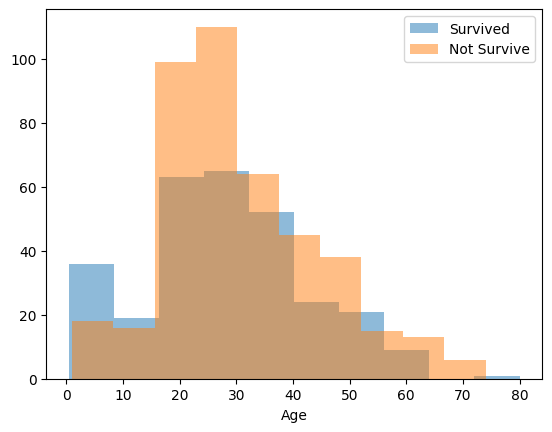

In [7]:
survived = modeling_df[modeling_df['Survived'] == 1]
not_survive = modeling_df[modeling_df['Survived'] == 0]

plt.hist(survived['Age'], alpha=.5, label='Survived')
plt.hist(not_survive['Age'], alpha=.5,  label= 'Not Survive')
plt.xlabel('Age')
plt.legend()
plt.show()

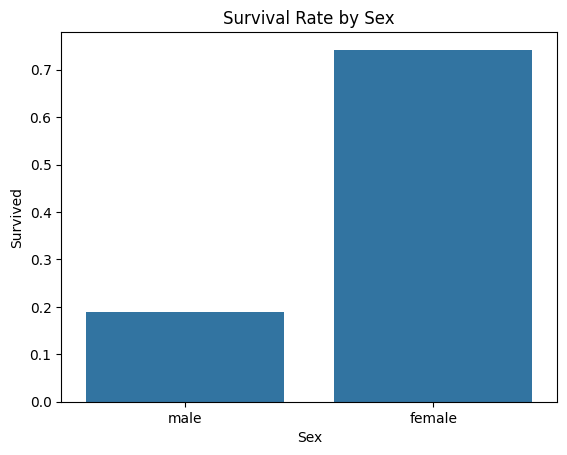

In [8]:
sns.barplot(x='Sex', y='Survived', data=df, errorbar=None)
plt.title("Survival Rate by Sex")
plt.show()

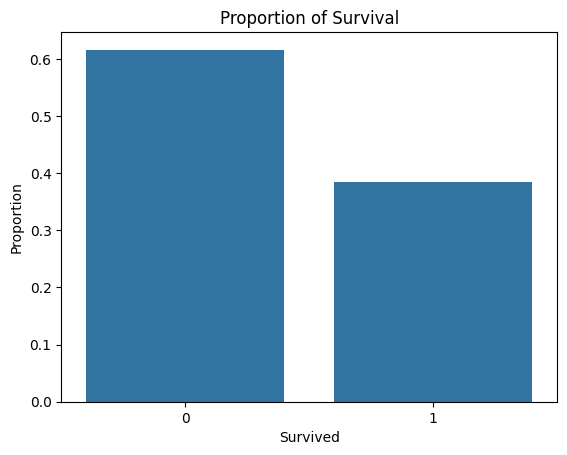

In [9]:
target_dist = pd.DataFrame(modeling_df['Survived'].value_counts(normalize=True))

target_dist.columns = ['Proportion']

sns.barplot(x='Survived', y='Proportion', data=target_dist)
plt.title('Proportion of Survival')
plt.xlabel('Survived')
plt.ylabel('Proportion')
plt.xticks(rotation=0)
plt.show()

In [10]:
# # corr_df = modeling_df.drop(columns=drop_cols).copy()

# plt.figure(figsize=(16,16))
# corr =  modeling_df.corr()
# sns.heatmap(corr, cmap='Blues', annot=True, fmt=".2f")
# plt.title("Correlation Heatamap")
# plt.show()

In [11]:
modeling_df.describe()
modeling_df.to_clipboard()

In [12]:
model = LogisticRegression()
model.fit(x_train_transformed, y_train)

y_pred = model.predict(x_test_transformed)

print("Classification Report WITHOUT Hyperparameter tuning")
print(classification_report(y_test, y_pred))

Classification Report WITHOUT Hyperparameter tuning
              precision    recall  f1-score   support

           0       0.81      0.85      0.83       157
           1       0.78      0.72      0.75       111

    accuracy                           0.80       268
   macro avg       0.79      0.79      0.79       268
weighted avg       0.80      0.80      0.80       268



In [13]:
# param_grid = [
#     {'penalty' : ['l1', 'l2', 'elasticnet', 'none'],
#      'C': np.logspace(-4,4,20),
#      'solver': ['lbfgs', 'newton-cg', 'liblinear', 'sag', 'saga'],
#      'max_iter': [100,1000,2500,5000]}
# ]

param_grid = [
    # solvers that only support l2 or none
    {
        'penalty': ['l2', None],
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'C': np.logspace(-4, 4, 20),
        'max_iter': [100, 1000, 2500, 5000]
    },
    # liblinear supports l1 and l2
    {
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear'],
        'C': np.logspace(-4, 4, 20),
        'max_iter': [100, 1000, 2500, 5000]
    },
    # saga supports all penalties but elasticnet requires l1_ratio
    {
        'penalty': ['l1', 'l2'],
        'solver': ['saga'],
        'C': np.logspace(-4, 4, 20),
        'max_iter': [100, 1000, 2500, 5000]
    },
    # elasticnet with saga (requires l1_ratio)
    {
        'penalty': ['elasticnet'],
        'solver': ['saga'],
        'l1_ratio': [0.1, 0.5, 0.9],
        'C': np.logspace(-4, 4, 20),
        'max_iter': [100, 1000, 2500, 5000]
    }
]

In [14]:
clf = GridSearchCV(model, param_grid=param_grid, cv=3, verbose=True, n_jobs=-1, error_score='raise')
clf

GridSearchCV(cv=3, error_score='raise', estimator=LogisticRegression(),
             n_jobs=-1,
             param_grid=[{'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559...
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                          'l1_ratio': [0.1, 0.5, 0.9],
                          'max_iter': [100, 1000, 2500, 5000],
                          'penalty': ['elasticnet'], 'solver': ['saga']}],
             verbose=True)

In [15]:
best_model = clf.fit(x_train_transformed, y_train)
best_model.best_estimator_

Fitting 3 folds for each of 1040 candidates, totalling 3120 fits


/Users/loganheydt/Desktop/Data/GitHub/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/loganheydt/Desktop/Data/GitHub/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/loganheydt/Desktop/Data/GitHub/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/loganheydt/Desktop/Data/GitHub/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(
/Users/loganheydt/Desktop/Data/GitHub/.venv/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:1207: UserWarning: Setting penalty=None will ignore the C and l1_ratio par

LogisticRegression(C=np.float64(0.23357214690901212), penalty='l1',
                   solver='liblinear')

In [16]:
y_pred_best = best_model.predict(x_test_transformed)

print("Classification Report WITH Hyperparameter tuning")
print(classification_report(y_test, y_pred_best))

Classification Report WITH Hyperparameter tuning
              precision    recall  f1-score   support

           0       0.80      0.85      0.82       157
           1       0.77      0.69      0.73       111

    accuracy                           0.79       268
   macro avg       0.78      0.77      0.78       268
weighted avg       0.79      0.79      0.79       268



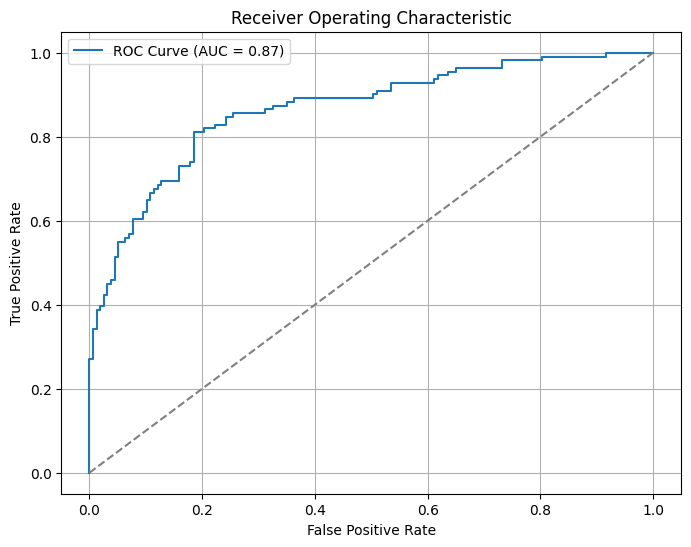

In [17]:
y_prob = best_model.predict_proba(x_test_transformed)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
#  DONE 
# train test split goes before anything you do
#       look at mayrent pre-proccessing pipeline

# TO DO
# more exploration 
# feature importace and coeff

# try lightgbm or xgboost

